In [2]:
# import h5py
import numpy as np
import matplotlib.pyplot as plt
# import glob
# import sys
# from itertools import groupby
# from operator import itemgetter
import matplotlib.colors as colors
# import seaborn as sns

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.optimize import least_squares

In [6]:
c_200 = np.load("results/200K_1000samples_size800/Cov.npy")

In [5]:
def transform_cov_for_1D(cov, display_bin):
    rows, cols = cov.shape
    col_indices = (np.arange(rows)[:, None] + np.arange(cols)) % cols
    small_cov = cov[np.arange(rows)[:, None], col_indices][:, :display_bin]
    return small_cov/np.max(small_cov, axis=1)[:, None]

In [8]:
display_bin = 100
s_200 = transform_cov_for_1D(c_200, display_bin)
mean_200 = np.mean(s_200, axis=0)
stds_200 = np.std(s_200, axis=0)

In [17]:
def try_fit(func, step, leg, title, cov_mean, p0=None):
    # start with fitting data
    ent = len(cov_mean)
    data = cov_mean/cov_mean[0]
    x = np.arange(ent)*1.2
    f = interp1d(x, data) # interpolation

    x_smooth = np.arange(0, x[-1], step)
    popt, pcov = curve_fit(func, x_smooth, f(x_smooth), p0=p0, maxfev=10000) #curve_fit
    print(popt)

    unc = np.sqrt(np.diag(pcov))

    string_fn = np.vectorize(lambda x: f"{x:.2f}")
    string_popt = ", ".join(string_fn(popt))
    string_unc = ", ".join(string_fn(unc))

    # calculate statistical measurements
    y = func(x, *popt)
    diff = y-data
    rmse = np.sqrt(np.mean(diff**2)) #Root mean square

    n = ent
    k = len(popt)
    RSS = np.sum(diff**2)
    BIC = k*np.log(n) - 2*np.log(RSS/n) # Baysian Information Criterion -- Evaluates loss in info from having parameters. Tends to favor simpler models than AIC.

    #Plots
    y_smooth = func(x_smooth, *popt)

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3,1], "hspace":0})

    # vertical lines
    # for j in range(2):
    #      for i in range(ent):
    #         axes[j].axvline(i*5, c="lightgray", linestyle="--")

    # first plot
    axes[0].plot(x, data, label="Cov", c="tab:blue")
    axes[0].plot(x_smooth, y_smooth, c="tab:orange", label=f"scipy optimized fit\n"+rf"({leg}) = ({string_popt})"+"\n"+rf"$\delta$({leg}) = ({string_unc})")

    axes[0].set_ylabel(r"Normalized Cov($\Delta t$)")
    axes[0].legend()
    axes[0].spines["bottom"].set_linewidth(2.0)

    # residual plot
    axes[1].axhline(y=0, c="gray", linestyle="--")
    axes[1].plot(x, diff, label=f"RMSE = {rmse:.2f}\nBIC = {BIC:.2f}")

    axes[1].set_ylabel(r"Residual")
    axes[1].legend()

    plt.xlabel(r"$\Delta t$ [ns]")
    axes[0].set_title(rf"{title}, ent={ent}, step={step}, p0={p0}")

    plt.show()

In [11]:
def sinc_func(x, A, omega):
    return A*np.sinc(omega*x)

[0.68077402 0.33616772]


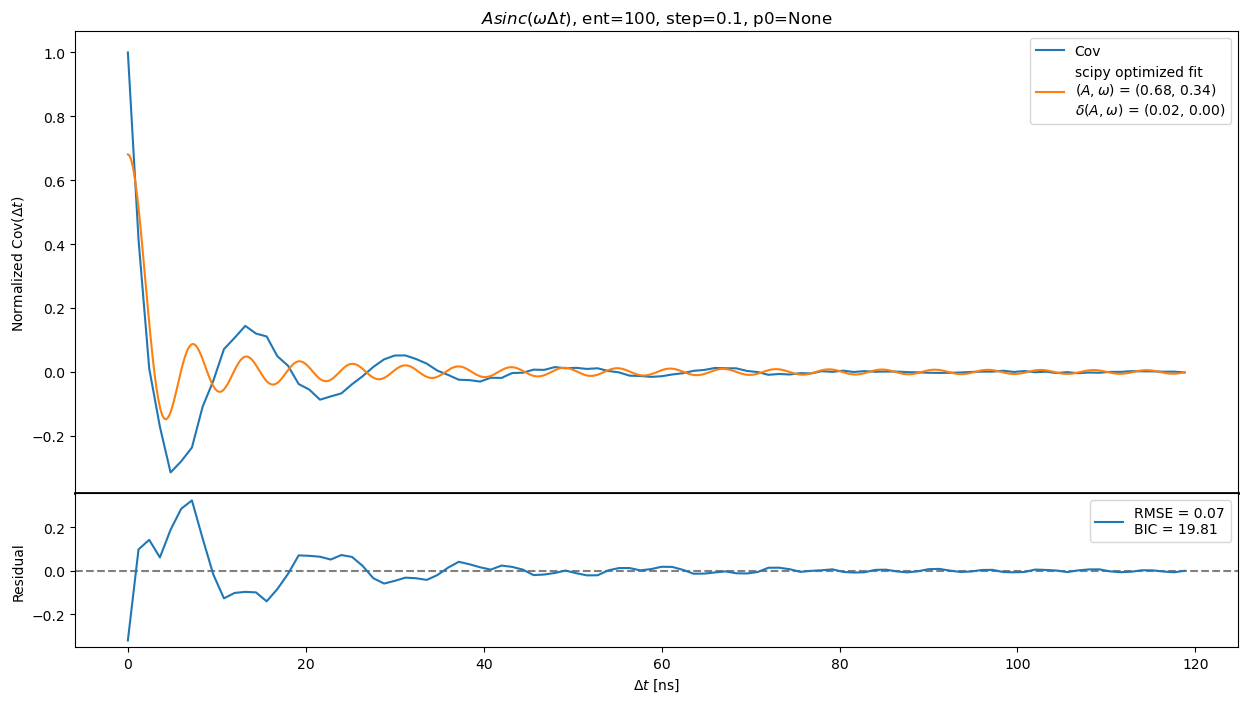

In [18]:
try_fit(sinc_func, 0.1, r"$A, \omega$", r"$A sinc(\omega \Delta t)$", mean_200)